(973, 26)
Fold 1 | Train: 778 rows (132 college) | Val: 195 rows (34 college)
Fold 2 | Train: 778 rows (133 college) | Val: 195 rows (33 college)
Fold 3 | Train: 778 rows (133 college) | Val: 195 rows (33 college)
Fold 4 | Train: 779 rows (133 college) | Val: 194 rows (33 college)
Fold 5 | Train: 779 rows (133 college) | Val: 194 rows (33 college)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- QB Model Comparison ---
Random Forest RMSE: 5.2349
XGBoost RMSE:       5.2606


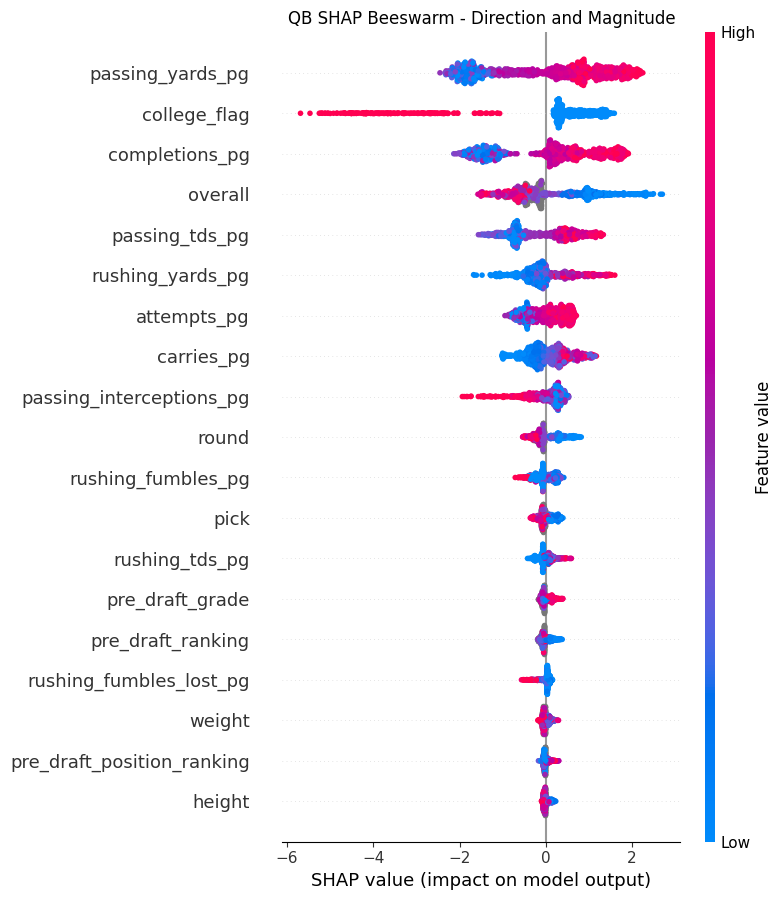

QB RF model saved


In [2]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import joblib
import json

# Load data
df_qb = pd.read_csv("../data/processed/qb_combined_training.csv")
print(df_qb.shape)

# Features and target
X_qb = df_qb.drop(columns=["player_id", "player_display_name", "season",
                             "target_fp_ppr", "target_games", "games", "fumble_recovery_own_pg"])
y_qb = df_qb["target_fp_ppr"]
strat_qb = df_qb["college_flag"]

# CV folds
kf_qb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_indices_qb = list(kf_qb.split(X_qb, strat_qb))

for fold, (train_idx, val_idx) in enumerate(cv_indices_qb):
    train_college = strat_qb.iloc[train_idx].sum()
    val_college = strat_qb.iloc[val_idx].sum()
    print(f"Fold {fold+1} | Train: {len(train_idx)} rows ({train_college} college) | Val: {len(val_idx)} rows ({val_college} college)")

# RF tuning
param_grid_rf = {
    "n_estimators": [300, 500, 750],
    "max_features": ["sqrt", 0.4, 0.6],
    "min_samples_leaf": [2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_depth": [None, 10, 20, 30]
}

rf_qb = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=40, scoring="neg_root_mean_squared_error",
    cv=cv_indices_qb, random_state=42, n_jobs=-1, verbose=1
)
rf_qb.fit(X_qb, y_qb)

# XGBoost tuning
param_grid_xgb = {
    "n_estimators": [300, 500, 750],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 2, 5]
}

xgb_qb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid_xgb,
    n_iter=40, scoring="neg_root_mean_squared_error",
    cv=cv_indices_qb, random_state=42, n_jobs=-1, verbose=1
)
xgb_qb.fit(X_qb, y_qb)

print("\n--- QB Model Comparison ---")
print(f"Random Forest RMSE: {-rf_qb.best_score_:.4f}")
print(f"XGBoost RMSE:       {-xgb_qb.best_score_:.4f}")

# Fit best model
best_model_qb = rf_qb.best_estimator_ if -rf_qb.best_score_ < -xgb_qb.best_score_ else xgb_qb.best_estimator_
model_name_qb = "rf" if -rf_qb.best_score_ < -xgb_qb.best_score_ else "xgb"
best_model_qb.fit(X_qb, y_qb)

# SHAP
explainer_qb = shap.TreeExplainer(best_model_qb)
shap_values_qb = explainer_qb.shap_values(X_qb)

shap.summary_plot(shap_values_qb, X_qb, show=False)
plt.title("QB SHAP Beeswarm - Direction and Magnitude")
plt.tight_layout()
plt.show()

# Save model, features and metadata
joblib.dump(best_model_qb, f"best_{model_name_qb}_qb_model.joblib")
feature_cols_qb = X_qb.columns.tolist()
with open(f"{model_name_qb}_qb_feature_cols.json", "w") as f:
    json.dump(feature_cols_qb, f)

metadata_qb = {
    "model_name": model_name_qb,
    "rf_rmse": -rf_qb.best_score_,
    "xgb_rmse": -xgb_qb.best_score_
}
with open("qb_model_metadata.json", "w") as f:
    json.dump(metadata_qb, f)

print(f"QB {model_name_qb.upper()} model saved")